In [1]:
import pandas as pd
from pathlib import Path

# Pasta onde estão os arquivos brutos da SUSEP
RAW_DIR = Path("../data/raw")

# Mapeamento arquivo -> nome da empresa
arquivos_empresas = {
    "mes_bradesco.xls": "Bradesco Seguros",
    "mes_porto.xls": "Porto",
    "mes_tokio.xls": "Tokio Marine",
    "mes_allianz.xls": "Allianz",
    "mes_mapfre.xls": "Mapfre",
}

dfs = []

for arquivo, empresa in arquivos_empresas.items():
    caminho = RAW_DIR / arquivo
    # pd.read_html porque os "xls" da SUSEP são HTML disfarçado
    tabelas = pd.read_html(caminho)
    df = tabelas[0]  # a primeira tabela é sempre os dados
    df["empresa"] = empresa
    dfs.append(df)
    print(f"{empresa}: {df.shape[0]} linhas carregadas")

df_bruto = pd.concat(dfs, ignore_index=True)
print(f"\nTotal consolidado: {df_bruto.shape[0]} linhas")
df_bruto.head()

Bradesco Seguros: 66 linhas carregadas
Porto: 66 linhas carregadas
Tokio Marine: 66 linhas carregadas
Allianz: 66 linhas carregadas
Mapfre: 66 linhas carregadas

Total consolidado: 330 linhas


,Competência,Prêmio Direto ¹,Prêmio Emitido (Reg. Capitalização) ³,Prêmio Seguros ¹,Prêmio Retido ²,Prêmio Emitido ³,Prêmio Ganho ¹,Despesa com Resseguro ³,Sinistro de Seguros ²,Sinistro Retido ²,Sinistro Ocorrido ³,Receita com Resseguro ³,Sinistro Ocorridos (Cap) ³,Recuperação de Sinistros Ocorridos (Cap) ³,Despesa Comercial,Sinistralidade ¹,RVNE ³,Convênio DPVAT ³,Consórcios e Fundos ³,empresa
0,202101,292.641.308,0,287.336.263,0,287.336.263,333.063.431,0,0,0,198.882.092,0,0,0,57.358.853,60,"-5.305.044,88",0,0,Bradesco Seguros
1,202102,290.061.973,0,288.755.902,0,288.755.902,303.329.197,0,0,0,182.396.699,0,0,0,51.096.709,60,"-1.306.070,50",0,0,Bradesco Seguros
2,202103,378.199.915,0,387.115.961,0,387.115.961,341.192.129,0,0,0,194.577.860,0,0,0,57.629.227,57,"8.916.046,43",0,0,Bradesco Seguros
3,202104,334.959.883,0,332.769.696,0,332.769.696,328.855.373,0,0,0,187.535.344,0,0,0,56.608.474,57,"-2.190.187,56",0,0,Bradesco Seguros
4,202105,367.241.551,0,382.346.459,0,382.346.459,346.466.706,0,0,0,204.428.206,0,0,0,59.235.215,59,"15.104.908,03",0,0,Bradesco Seguros


In [2]:
import re

def limpar_valor_monetario(valor):
    """Converte string BR (ex: '292.641.308' ou '-5.305.044,88') para float."""
    if pd.isna(valor) or valor == 0:
        return 0.0
    valor = str(valor).strip()
    valor = valor.replace(".", "").replace(",", ".")
    return float(valor)

df = df_bruto.copy()

# Remove a linha de totais que a SUSEP inclui no final de cada tabela
df = df[df["Competência"] != "Totais"].copy()

# Padroniza nomes de colunas: sem acento, sem espaço, sem símbolos
df.columns = (
    df.columns
    .str.normalize("NFKD").str.encode("ascii", errors="ignore").str.decode("utf-8")
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

print("Colunas padronizadas:", list(df.columns))

df["competencia"] = pd.to_datetime(df["competencia"].astype(str), format="%Y%m")

colunas_monetarias = [
    c for c in df.columns
    if c not in ["competencia", "empresa", "sinistralidade_1", "rvne_3"]
]

for col in colunas_monetarias:
    df[col] = df[col].apply(limpar_valor_monetario)

print(f"\nShape final: {df.shape}")
df.dtypes

Colunas padronizadas: ['competencia', 'premio_direto_1', 'premio_emitido_reg_capitalizacao_3', 'premio_seguros_1', 'premio_retido_2', 'premio_emitido_3', 'premio_ganho_1', 'despesa_com_resseguro_3', 'sinistro_de_seguros_2', 'sinistro_retido_2', 'sinistro_ocorrido_3', 'receita_com_resseguro_3', 'sinistro_ocorridos_cap_3', 'recuperacao_de_sinistros_ocorridos_cap_3', 'despesa_comercial', 'sinistralidade_1', 'rvne_3', 'convenio_dpvat_3', 'consorcios_e_fundos_3', 'empresa']

Shape final: (325, 20)


competencia                                 datetime64[us]
premio_direto_1                                    float64
premio_emitido_reg_capitalizacao_3                 float64
premio_seguros_1                                   float64
premio_retido_2                                    float64
premio_emitido_3                                   float64
premio_ganho_1                                     float64
despesa_com_resseguro_3                            float64
sinistro_de_seguros_2                              float64
sinistro_retido_2                                  float64
sinistro_ocorrido_3                                float64
receita_com_resseguro_3                            float64
sinistro_ocorridos_cap_3                           float64
recuperacao_de_sinistros_ocorridos_cap_3           float64
despesa_comercial                                  float64
sinistralidade_1                                     int64
rvne_3                                                 s

empresa
Allianz             65
Bradesco Seguros    65
Mapfre              65
Porto               65
Tokio Marine        65
Name: competencia, dtype: int64

Data mínima: 2021-01-01 00:00:00
Data máxima: 2026-05-01 00:00:00

Valores nulos por coluna:
Series([], dtype: int64)



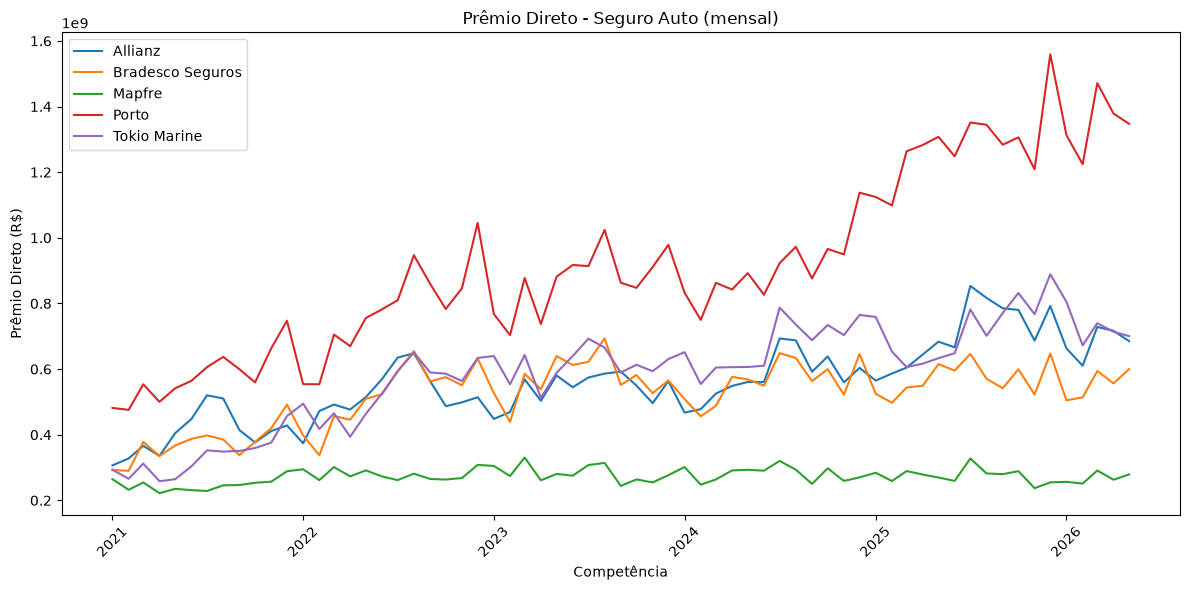

In [3]:
# 1. Confere se cada empresa tem exatamente 66 meses (jan/2021 a jun/2026)
print(df.groupby("empresa")["competencia"].count())
print()

# 2. Confere o range de datas
print("Data mínima:", df["competencia"].min())
print("Data máxima:", df["competencia"].max())
print()

# 3. Confere se tem valor nulo em alguma coluna
print("Valores nulos por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()

# 4. Visual rápido: prêmio direto por empresa ao longo do tempo
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
for empresa, grupo in df.groupby("empresa"):
    ax.plot(grupo["competencia"], grupo["premio_direto_1"], label=empresa)

ax.set_title("Prêmio Direto - Seguro Auto (mensal)")
ax.set_xlabel("Competência")
ax.set_ylabel("Prêmio Direto (R$)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()